In [1]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, LearningCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv("../data_&_analysis/reduced.csv")

data = data[data['text'].notna()]
data = data[data['label'].notna()]

print("Size of dataset: ", len(data))

Size of dataset:  22975


KNN, Count Vectorization

In [2]:
# splitting

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])

print("Size of training set: ", len(X_train))
print("Size of test set: ", len(X_test))

print("Training set classes distribution: ")
statistics = Y_train.value_counts()
print(statistics)

print("Test set classes distribution:")
statistics = Y_test.value_counts()
print(statistics)


Size of training set:  18380
Size of test set:  4595
Training set classes distribution: 
label
romance       5970
fantasy       5663
history       2158
thriller      1177
crime          856
psychology     718
science        657
horror         654
travel         320
sports         207
Name: count, dtype: int64
Test set classes distribution:
label
romance       1493
fantasy       1416
history        539
thriller       294
crime          214
psychology     180
science        164
horror         163
travel          80
sports          52
Name: count, dtype: int64


In [3]:
# vectorization & hyperparameter tuning - in this case, number of neighbors

count_vectorizer = CountVectorizer()

X_train = count_vectorizer.fit_transform(X_train)
X_test = count_vectorizer.transform(X_test)

knn_model = KNeighborsClassifier()

parameters = {
    "n_neighbors": [i for i in range(1,200,5)],
    "metric": ['euclidean'],
    "weights": ['uniform']
}

grid_search = GridSearchCV(
    knn_model, parameters, cv = 5, scoring="accuracy", n_jobs=1
)

grid_search.fit(X_train, Y_train)

print(f"Best score: {grid_search.best_score_:.4f}")
print(f"Best parameters:\n  {grid_search.best_params_}")



Best score: 0.4122
Best parameters:
  {'metric': 'euclidean', 'n_neighbors': 16, 'weights': 'uniform'}


In [4]:
# results of the best parameters on test set

best_params = grid_search.best_params_

knn_model = KNeighborsClassifier(n_neighbors=best_params["n_neighbors"], metric=best_params["metric"], weights=best_params["weights"])
knn_model.fit(X_train, Y_train)

Y_pred = knn_model.predict(X_test)
print("Test set results:")
print(metrics.classification_report(Y_test, Y_pred))

Test set results:
              precision    recall  f1-score   support

       crime       0.68      0.08      0.14       214
     fantasy       0.39      0.71      0.50      1416
     history       0.44      0.30      0.36       539
      horror       0.72      0.08      0.14       163
  psychology       0.75      0.10      0.18       180
     romance       0.46      0.48      0.47      1493
     science       0.86      0.04      0.07       164
      sports       0.00      0.00      0.00        52
    thriller       0.71      0.02      0.03       294
      travel       0.00      0.00      0.00        80

    accuracy                           0.42      4595
   macro avg       0.50      0.18      0.19      4595
weighted avg       0.48      0.42      0.37      4595



/home/wiktmm/uni/mpum/Genre-Classificator/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wiktmm/uni/mpum/Genre-Classificator/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wiktmm/uni/mpum/Genre-Classificator/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

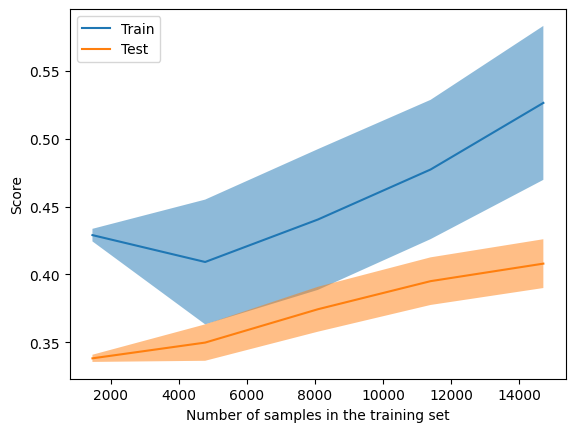

In [5]:
# learning curve for optimal number of neighbors

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=best_params["n_neighbors"])
cv = CountVectorizer()
X_train = cv.fit_transform(X_train)
LearningCurveDisplay.from_estimator(knn_model, X_train, Y_train)
plt.show()

In [6]:
target_genres = ['history', 'thriller', 'romance', 'fantasy', 'crime','science', 'psychology','travel','sports','horror']

def plot_confusion_matrix(Y, Y_pred, title, target_labels):
    matrix = metrics.confusion_matrix(Y, Y_pred, labels=target_labels)
    matrix_df = pd.DataFrame(matrix, columns=np.unique(target_labels), index=np.unique(target_labels))
    f, ax = plt.subplots(figsize=(10,5))
    ax = sns.heatmap(matrix_df, annot=True, fmt="g", cmap = "OrRd")

    ax.set_xlabel("Predicted values")
    ax.set_ylabel("Real values")
    ax.xaxis.set_ticklabels(target_genres)
    ax.yaxis.set_ticklabels(target_genres)
    
    plt.title(title)
    plt.show()

Accuracy:  0.36866158868335147


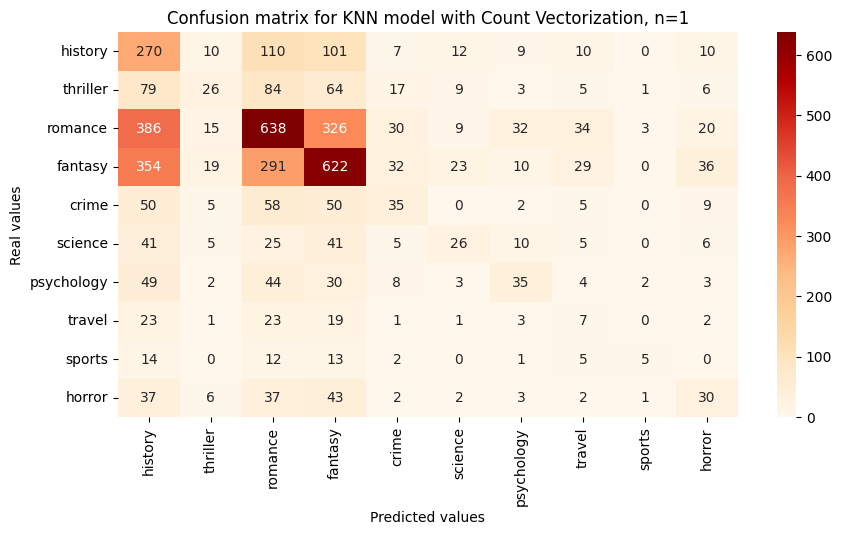

Accuracy:  0.3932535364526659


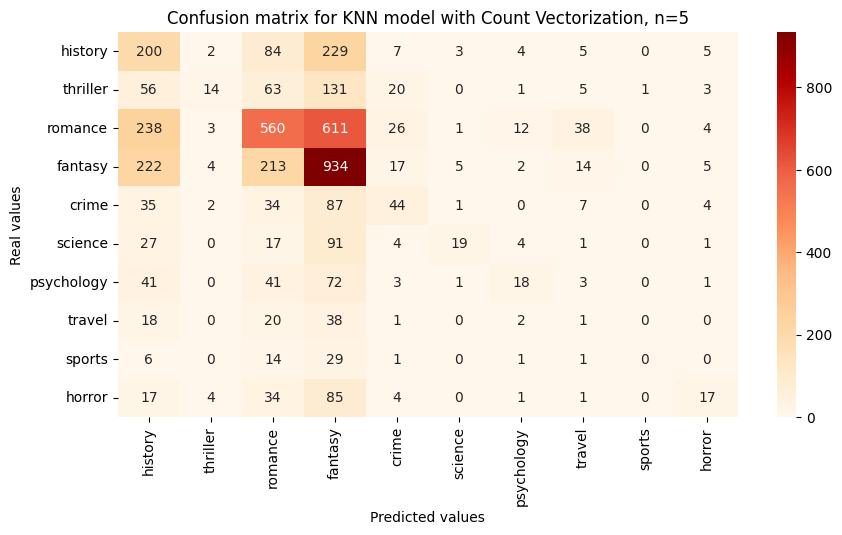

Accuracy:  0.40935799782372145


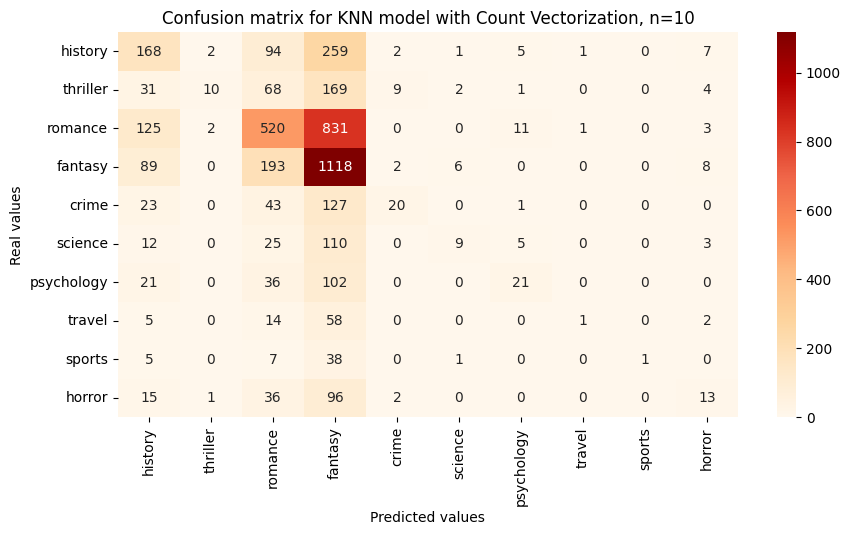

Accuracy:  0.3906420021762786


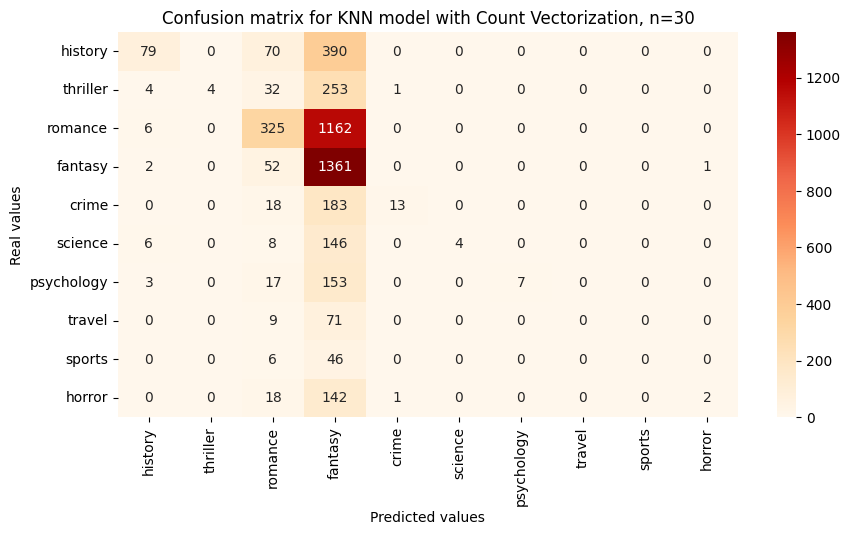

In [7]:
# confusion matrices across models with different parameters

count_vectorizer = CountVectorizer()

# 1 neighbor KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=1)
X_train = count_vectorizer.fit_transform(X_train)
X_test = count_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Count Vectorization, n=1", target_genres)

# 5 neighbors KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=5)
X_train = count_vectorizer.fit_transform(X_train)
X_test = count_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Count Vectorization, n=5", target_genres)



# 10 neighbors KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=10)
X_train = count_vectorizer.fit_transform(X_train)
X_test = count_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Count Vectorization, n=10", target_genres)

# 30 neighbors KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=30)
X_train = count_vectorizer.fit_transform(X_train)
X_test = count_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))


plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Count Vectorization, n=30", target_genres)

KNN with TFIDF Vectorizer

In [8]:
# hyperparameter tuning for KNN with Tfidf Vectorization

tfidf_vectorizer = TfidfVectorizer(max_df=0.95)

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], train_size=0.2, stratify=data['label'])
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model = KNeighborsClassifier()

parameters = {
    "n_neighbors": [i for i in range(1,200,5)],
    "metric": ['euclidean'],
    "weights": ['uniform', 'distance']
}

grid_search = GridSearchCV(
    knn_model, parameters, cv = 5, scoring="accuracy", n_jobs=1
)

grid_search.fit(X_train, Y_train)

print(f"Best score: {grid_search.best_score_:.4f}")
print(f"Best parameters:\n  {grid_search.best_params_}")

best_params = grid_search.best_params_


# Accuracy on test set for best parameters

knn_model = KNeighborsClassifier(n_neighbors=best_params["n_neighbors"], metric=best_params["metric"], weights=best_params["weights"])
knn_model.fit(X_train, Y_train)

Y_pred = knn_model.predict(X_test)
print("Test set results:")
print(metrics.classification_report(Y_test, Y_pred))


Best score: 0.6333
Best parameters:
  {'metric': 'euclidean', 'n_neighbors': 26, 'weights': 'distance'}
Test set results:
              precision    recall  f1-score   support

       crime       0.81      0.22      0.34       856
     fantasy       0.67      0.75      0.71      5663
     history       0.68      0.60      0.64      2158
      horror       0.71      0.07      0.14       654
  psychology       0.81      0.36      0.49       718
     romance       0.59      0.90      0.71      5970
     science       0.77      0.23      0.35       657
      sports       0.81      0.19      0.31       207
    thriller       0.71      0.09      0.15      1177
      travel       1.00      0.01      0.01       320

    accuracy                           0.64     18380
   macro avg       0.76      0.34      0.39     18380
weighted avg       0.67      0.64      0.59     18380



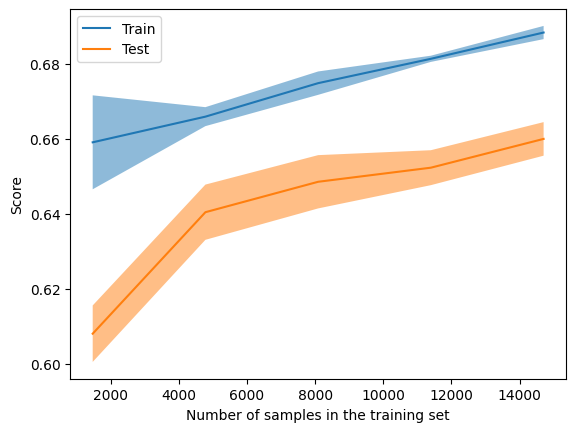

In [9]:
# learning curves for best parameter for the KNN model

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=best_params["n_neighbors"])
tfidf = TfidfVectorizer()
X_train = tfidf.fit_transform(X_train)

LearningCurveDisplay.from_estimator(knn_model,X_train,Y_train)

plt.show()

Accuracy:  0.5712731229597389


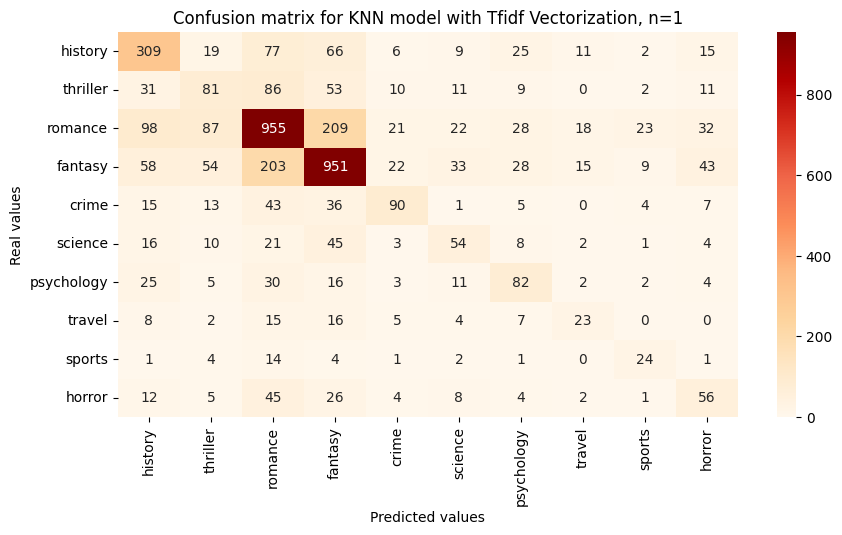

Accuracy:  0.6254624591947769


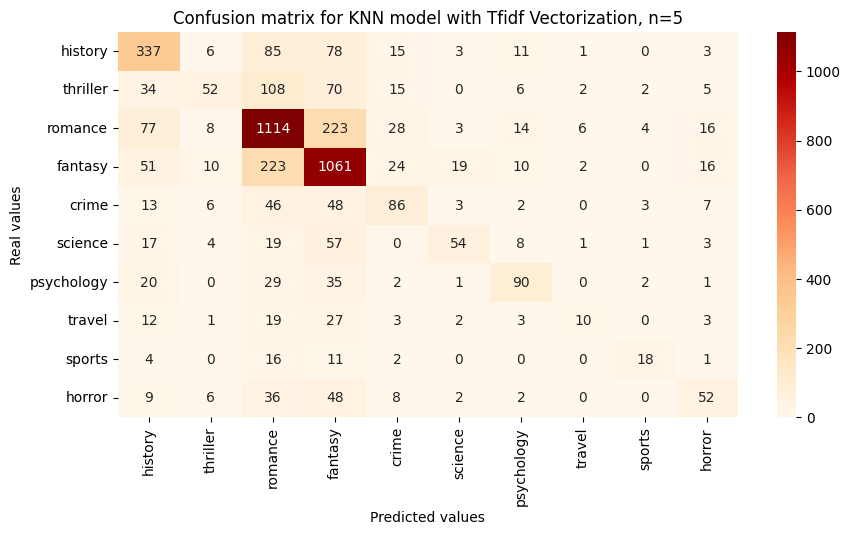

Accuracy:  0.6581066376496192


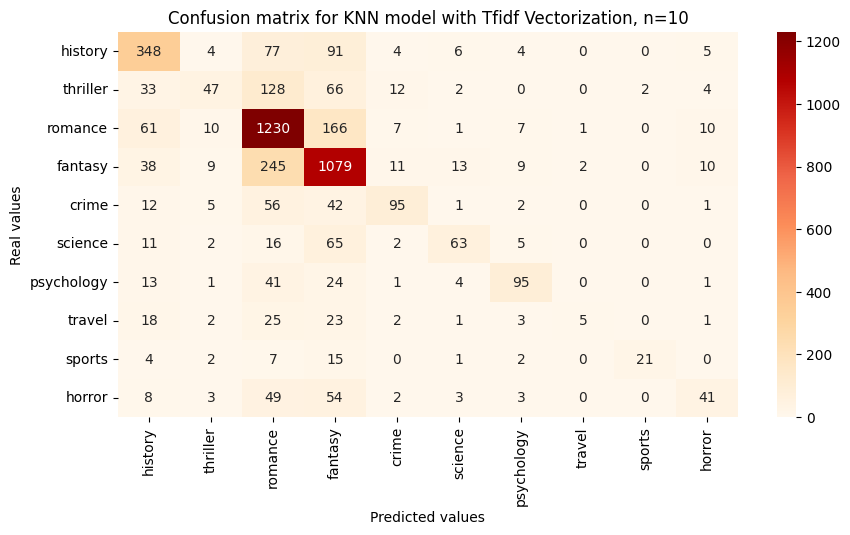

Accuracy:  0.6676822633297061


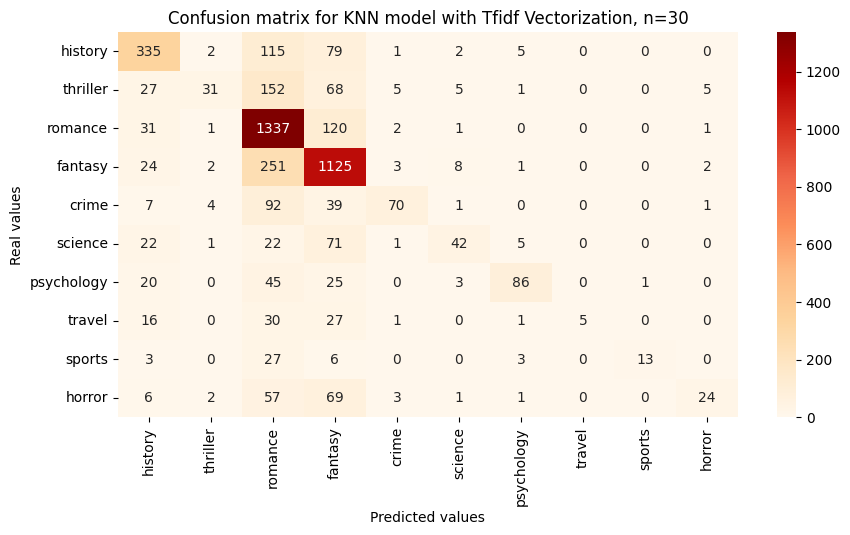

Accuracy:  0.66550598476605


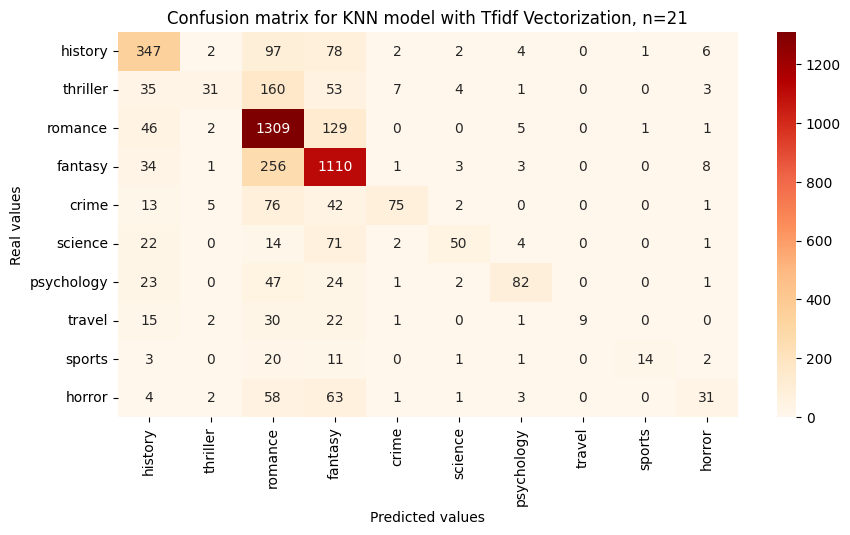

In [10]:
tfidf_vectorizer = TfidfVectorizer()

# 1 neighbor KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=1)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Tfidf Vectorization, n=1", target_genres)

# 5 neighbor KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=5)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Tfidf Vectorization, n=5", target_genres)

# 10 neighbor KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=10)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Tfidf Vectorization, n=10", target_genres)

# 30 neighbor KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=30)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Tfidf Vectorization, n=30", target_genres)

# 21 neighbor KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=21)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Tfidf Vectorization, n=21", target_genres)
